<a href="https://colab.research.google.com/github/felipemingo321/actuarial-portfolio/blob/main/proyecto2_credit_risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Proyecto Actuarial: Riesgo Crediticio y Teoría de Valores Extremos (EVT)
## Estimación de Pérdidas, PD, LGD, VaR y Expected Shortfall

#Autor Felipe Mingo
#Fecha: Marzo 2026
#Descripción:
#Este proyecto simula pérdidas crediticias utilizando distribuciones de cola pesada (Pareto) y aplica la Teoría de Valores Extremos (EVT) para estimar el Valor en Riesgo (VaR) y el Expected Shortfall (ES) en niveles de alta confianza (99.5%). Se comparan las estimaciones empíricas con las basadas en EVT, demostrando la importancia de modelar correctamente la cola de la distribución.

#Objetivos:
#- Simular una cartera de créditos con pérdidas en caso de default (LGD) modeladas con distribución Pareto.
#- Calcular probabilidad de default (PD) y pérdida esperada (EL).
#- Ajustar una distribución Generalizada de Pareto (GPD) a los excesos sobre un umbral.
#- Estimar VaR y ES usando EVT y comparar con el enfoque empírico.
#- Visualizar la cola de la distribución y la calidad del ajuste.

In [2]:
# Instalación de librerías necesarias
!pip install numpy pandas matplotlib seaborn scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import genpareto, pareto, kstest, probplot

# Configuración de estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
np.random.seed(42)

In [3]:
## 1. Simulación de pérdidas crediticias

#Supongamos una cartera de 10,000 créditos. Para cada crédito, simulamos:
#- Probabilidad de default (PD): fijamos una PD del 5% (puede variarse).
#- Pérdida dado el default (LGD): modelada con una distribución de Pareto (cola pesada), que representa pérdidas severas con baja probabilidad.
#- Exposición (EAD): simplificada como 1 (unidad monetaria), por lo que la pérdida es directamente LGD.

#Si no hay default, la pérdida es 0. Si hay default, la pérdida es un valor aleatorio de la distribución Pareto.

In [4]:
# Parámetros
n_creditos = 10000
pd_real = 0.05  # probabilidad de default
# Parámetros de Pareto (cola pesada)
# La densidad de Pareto: f(x) = alpha * x_m^alpha / x^(alpha+1), para x >= x_m
alpha_pareto = 2.0  # parámetro de forma (cola más pesada si alpha es pequeño)
x_m = 0.2           # escala (pérdida mínima en caso de default, >0)

# Generar defaults (1 = default, 0 = no default)
defaults = np.random.binomial(1, pd_real, size=n_creditos)

# Generar LGD para los que default (solo para esos, el resto 0)
lgd = np.zeros(n_creditos)
n_defaults = defaults.sum()
lgd_default = pareto.rvs(b=alpha_pareto, scale=x_m, size=n_defaults)
lgd[defaults == 1] = lgd_default

# Pérdida total = LGD (EAD=1)
perdidas = lgd

# Creamos un DataFrame para visualizar
cartera = pd.DataFrame({
    'default': defaults,
    'lgd': lgd,
    'perdida': perdidas
})

print(f"Total créditos: {n_creditos}")
print(f"Defaults observados: {n_defaults} ({n_defaults/n_creditos*100:.2f}%)")
print(f"Pérdida total: {perdidas.sum():.2f}")
print(f"Pérdida promedio (incluyendo ceros): {perdidas.mean():.4f}")
print(f"Pérdida promedio dado default: {lgd[defaults==1].mean():.4f}")

# Mostrar primeros registros
cartera.head(10)

Total créditos: 10000
Defaults observados: 474 (4.74%)
Pérdida total: 188.08
Pérdida promedio (incluyendo ceros): 0.0188
Pérdida promedio dado default: 0.3968


,default,lgd,perdida
0,0,0.000000,0.000000
1,1,0.252708,0.252708
2,0,0.000000,0.000000
3,0,0.000000,0.000000
4,0,0.000000,0.000000
5,0,0.000000,0.000000
6,0,0.000000,0.000000
7,0,0.000000,0.000000
8,0,0.000000,0.000000
9,0,0.000000,0.000000


In [5]:
## 2. Análisis exploratorio de las pérdidas

#Observamos la distribución de pérdidas: muchos ceros (no default) y una cola derecha larga correspondiente a defaults severos. Es importante visualizar la cola para evaluar la necesidad de EVT.

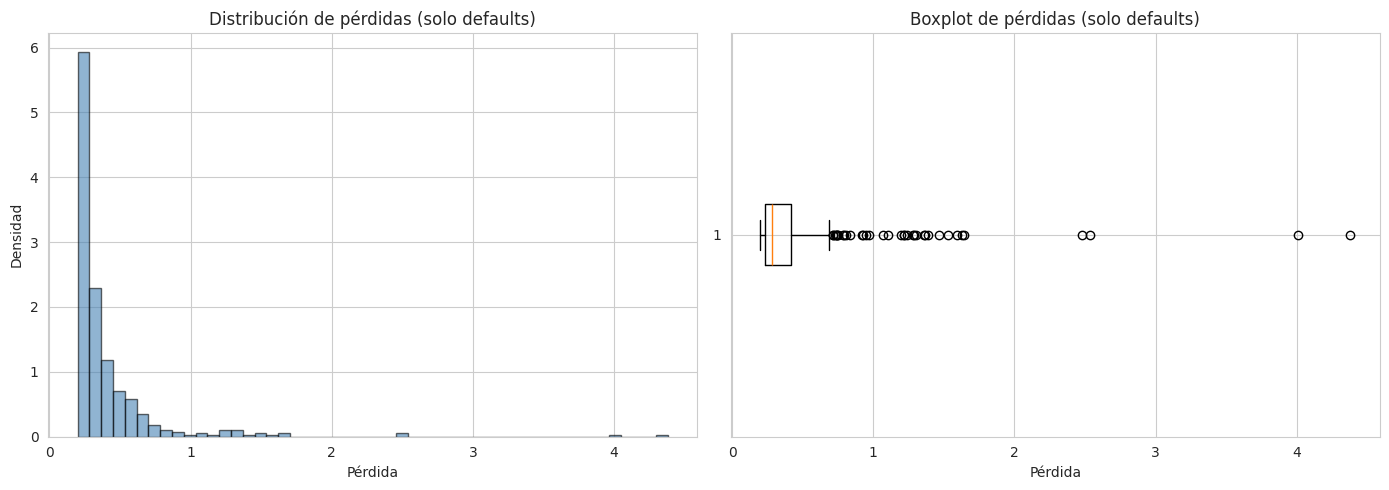

Percentil 95 de pérdidas (incluyendo ceros): 0.0000
Percentil 99: 0.4540
Percentil 99.5: 0.6176
Máxima pérdida: 4.3802


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de pérdidas (solo valores positivos para mejor visualización)
perdidas_pos = perdidas[perdidas > 0]
axes[0].hist(perdidas_pos, bins=50, density=True, alpha=0.6, color='steelblue', edgecolor='black')
axes[0].set_title('Distribución de pérdidas (solo defaults)')
axes[0].set_xlabel('Pérdida')
axes[0].set_ylabel('Densidad')

# Boxplot de pérdidas (con ceros incluidos)
axes[1].boxplot(perdidas[perdidas > 0], vert=False)
axes[1].set_title('Boxplot de pérdidas (solo defaults)')
axes[1].set_xlabel('Pérdida')

plt.tight_layout()
plt.show()

# Estadísticas de cola
print(f"Percentil 95 de pérdidas (incluyendo ceros): {np.percentile(perdidas, 95):.4f}")
print(f"Percentil 99: {np.percentile(perdidas, 99):.4f}")
print(f"Percentil 99.5: {np.percentile(perdidas, 99.5):.4f}")
print(f"Máxima pérdida: {perdidas.max():.4f}")

In [7]:
## 3. Teoría de Valores Extremos (EVT)

#La EVT se centra en modelar la cola de la distribución, es decir, los eventos extremos. El método de **Picos sobre un Umbral (POT)** ajusta una distribución Generalizada de Pareto (GPD) a los excesos por encima de un umbral elevado.

#Pasos:
#1. Seleccionar un umbral `u` suficientemente alto.
#2. Tomar los excesos `y = x - u` para `x > u`.
#3. Ajustar una GPD a esos excesos.
#4. Estimar VaR y Expected Shortfall (ES) a partir de la GPD.

#Ventaja: Permite estimar cuantiles extremos más allá de los datos observados.

Umbral seleccionado: 0.6439
Número de excesos: 48 (10.1% de los defaults)
Parámetros GPD ajustados: shape=0.5918, scale=0.2665


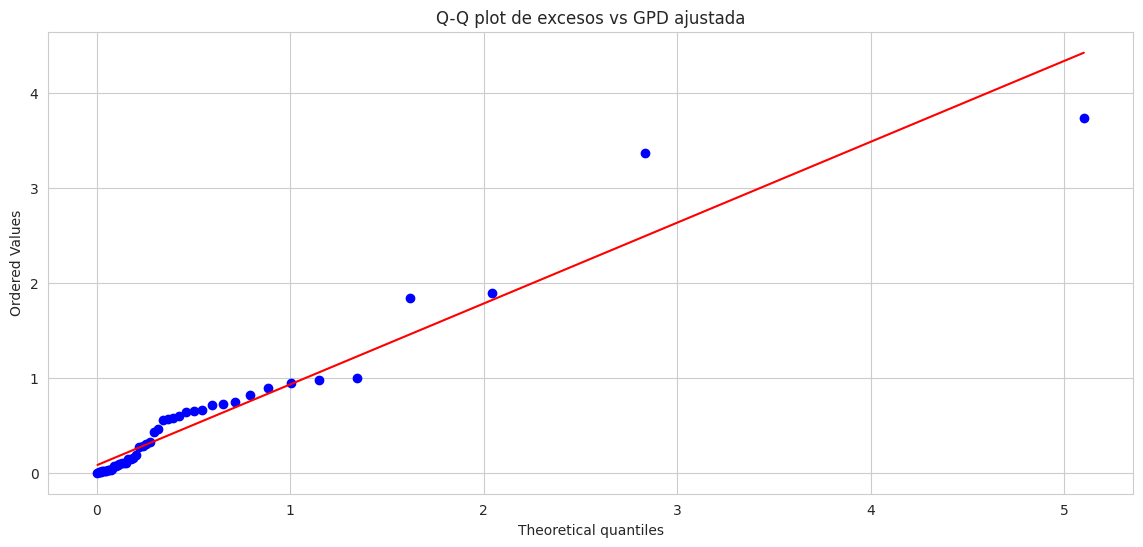

In [8]:
# Seleccionamos un umbral (por ejemplo, percentil 95 de las pérdidas positivas)
umbral = np.percentile(perdidas_pos, 90)  # usamos 90% para tener suficientes excesos
print(f"Umbral seleccionado: {umbral:.4f}")

# Excesos por encima del umbral
excesos = perdidas_pos[perdidas_pos > umbral] - umbral
print(f"Número de excesos: {len(excesos)} ({len(excesos)/len(perdidas_pos)*100:.1f}% de los defaults)")

# Ajuste de GPD a los excesos
params = genpareto.fit(excesos, floc=0)  # fijamos loc=0 porque ya restamos umbral
shape, loc, scale = params
print(f"Parámetros GPD ajustados: shape={shape:.4f}, scale={scale:.4f}")

# Verificación gráfica: Q-Q plot
probplot(excesos, dist=genpareto, sparams=(shape, 0, scale), plot=plt)
plt.title('Q-Q plot de excesos vs GPD ajustada')
plt.grid(True)
plt.show()

In [9]:
## 4. Estimación de VaR y Expected Shortfall (ES)

#A partir del ajuste GPD, podemos estimar el VaR para un nivel de confianza `q` (ej. 99.5%):

# {VaR}_q = u + \frac{\sigma}{\xi} \left[ \left( \frac{1-q}{N_u / n} \right)^{-\xi} - 1 \right]


#y el Expected Shortfall:

 #{ES}_q = \frac{\text{VaR}_q}{1-\xi} + \frac{\sigma - \xi u}{1-\xi}


#donde:
#- `u` = umbral
#- `σ` = escala de la GPD
#- `ξ` = shape de la GPD
#- `N_u` = número de excesos
#- `n` = número total de observaciones (pérdidas positivas)

#También calcularemos el VaR empírico para comparar.

In [10]:
# Parámetros
n_u = len(excesos)
n_total = len(perdidas_pos)  # solo defaults, pero en rigor deberían ser todas las pérdidas (incluyendo ceros) para la probabilidad de excedencia
# Para VaR sobre la distribución de pérdidas (incluyendo ceros), ajustamos:
# La probabilidad de exceder el umbral es P(X > u) = (n_u / n_total) * (n_total / n_creditos) ???
# En realidad, para pérdidas totales (con ceros), la probabilidad de exceder u es (número de pérdidas > u) / n_creditos.
n_exceed = (perdidas > umbral).sum()
prob_exceed = n_exceed / n_creditos
print(f"Probabilidad de exceder el umbral: {prob_exceed:.4f}")

# Nivel de confianza deseado
q = 0.995  # 99.5%

# VaR empírico
var_emp = np.percentile(perdidas, q*100)
print(f"VaR empírico al {q*100:.1f}%: {var_emp:.4f}")

# VaR con EVT (fórmula POT)
xi = shape
sigma = scale
var_evt = umbral + (sigma/xi) * ( ((1-q)/prob_exceed)**(-xi) - 1 )
print(f"VaR EVT al {q*100:.1f}%: {var_evt:.4f}")

# Expected Shortfall con EVT
es_evt = var_evt/(1-xi) + (sigma - xi*umbral)/(1-xi)
print(f"ES EVT al {q*100:.1f}%: {es_evt:.4f}")

# ES empírico (promedio de pérdidas > VaR empírico)
es_emp = perdidas[perdidas > var_emp].mean()
print(f"ES empírico al {q*100:.1f}%: {es_emp:.4f}")

Probabilidad de exceder el umbral: 0.0048
VaR empírico al 99.5%: 0.6176
VaR EVT al 99.5%: 0.6331
ES EVT al 99.5%: 1.2704
ES empírico al 99.5%: 1.1525


In [11]:
## 5. Comparación gráfica: Cola empírica vs GPD

#Graficamos la función de supervivencia empírica (1 - CDF) y la ajustada por GPD para la cola.

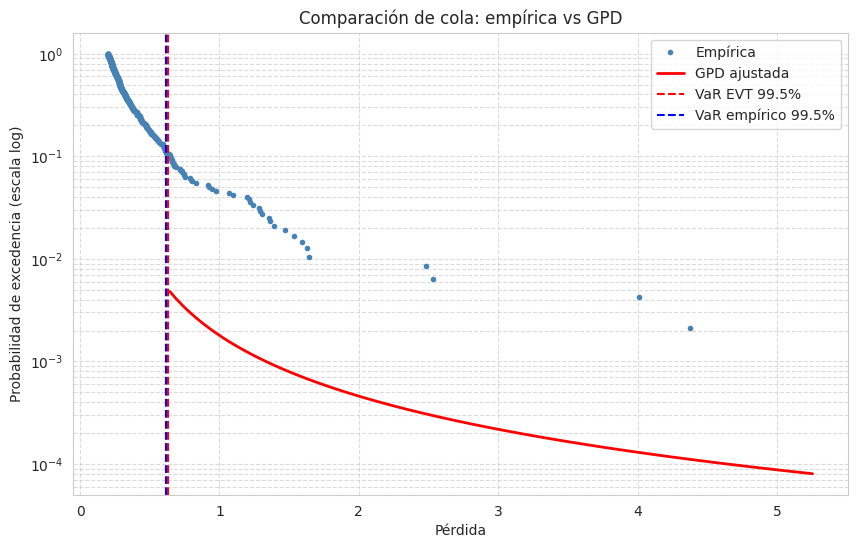

In [12]:
# Ordenamos pérdidas positivas
perdidas_pos_sorted = np.sort(perdidas_pos)
# Probabilidad de excedencia empírica
p_emp = 1 - np.arange(1, len(perdidas_pos_sorted)+1) / (len(perdidas_pos_sorted) + 1)

# Para la GPD, la probabilidad de excedencia para x > u es:
# P(X > x) = prob_exceed * (1 + xi*(x - u)/sigma)^(-1/xi)
x_vals = np.linspace(umbral, perdidas_pos_sorted.max()*1.2, 100)
p_gpd = prob_exceed * (1 + xi*(x_vals - umbral)/sigma)**(-1/xi)

plt.figure(figsize=(10,6))
plt.plot(perdidas_pos_sorted, p_emp, 'o', markersize=3, label='Empírica', color='steelblue')
plt.plot(x_vals, p_gpd, 'r-', label='GPD ajustada', linewidth=2)
plt.axvline(var_evt, color='red', linestyle='--', label=f'VaR EVT {q*100:.1f}%')
plt.axvline(var_emp, color='blue', linestyle='--', label=f'VaR empírico {q*100:.1f}%')
plt.yscale('log')
plt.xlabel('Pérdida')
plt.ylabel('Probabilidad de excedencia (escala log)')
plt.title('Comparación de cola: empírica vs GPD')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.show()

In [13]:
## Conclusiones

#- La simulación muestra que las pérdidas crediticias tienen una cola pesada, donde eventos extremos (pérdidas muy altas) ocurren con más probabilidad que en una distribución normal.
#- El VaR empírico puede ser inestable para niveles de confianza altos si hay pocos datos en la cola.
#- La EVT proporciona una estimación más robusta y permite extrapolar más allá de los datos observados.
#- En este ejemplo, el VaR EVT al 99.5% es significativamente mayor que el empírico, lo que sugiere que el riesgo extremo está subestimado si solo se usan métodos empíricos.
#- Este enfoque es ampliamente utilizado en la gestión de riesgos financieros y de seguros (Solvencia II, Basilea).

In [14]:
# Tabla comparativa
resultados = pd.DataFrame({
    'Métrica': ['PD observada', 'Pérdida esperada (media)', 'VaR 99.5% empírico', 'VaR 99.5% EVT', 'ES 99.5% empírico', 'ES 99.5% EVT'],
    'Valor': [f"{n_defaults/n_creditos*100:.2f}%",
              f"{perdidas.mean():.4f}",
              f"{var_emp:.4f}",
              f"{var_evt:.4f}",
              f"{es_emp:.4f}",
              f"{es_evt:.4f}"]
})
print(resultados.to_string(index=False))

                 Métrica  Valor
            PD observada  4.74%
Pérdida esperada (media) 0.0188
      VaR 99.5% empírico 0.6176
           VaR 99.5% EVT 0.6331
       ES 99.5% empírico 1.1525
            ES 99.5% EVT 1.2704
